1. Open a Linux Terminal

All commands in this section must be executed in a Linux terminal, not in a Jupyter Notebook.

2. Create a New Conda Environment
conda create -n gis python=3.11 -y

Activate the environment:

conda activate gis

You should see something like:

(gis) user@computer:~$
3. Install GIS Packages

Run in the terminal:

conda install -c conda-forge jupyter ipykernel geopandas rasterio gdal fiona shapely pyproj folium leafmap -y

Wait until Conda finishes downloading and installing all packages.

4. Register the Environment in Jupyter

Run in the terminal:

python -m ipykernel install --user --name gis --display-name "Python (GIS)"
5. Start Jupyter Notebook

Run in the terminal:

jupyter notebook

A browser window should open automatically.

If it does not, copy and paste the URL shown in the terminal into your browser.

Inside the Jupyter Notebook

After Jupyter opens:

Click New → Python (GIS).
Create a new notebook.

Everything below is executed in Notebook cells, not in the terminal.

Test the Installation
import geopandas as gpd

print(gpd.__version__)

If a version number appears, GeoPandas is installed correctly.

Test GDAL
from osgeo import gdal

print(gdal.VersionInfo())
Test Rasterio
import rasterio

print(rasterio.__version__)
Test an Interactive Map
import folium

m = folium.Map(location=[39.22, 9.12], zoom_start=10)
m
Quick Reference
Terminal (Linux Shell)
conda create -n gis python=3.11 -y
conda activate gis
conda install -c conda-forge jupyter ipykernel geopandas rasterio gdal fiona shapely pyproj folium leafmap -y
python -m ipykernel install --user --name gis --display-name "Python (GIS)"
jupyter notebook
Notebook Cell
import geopandas as gpd
import rasterio
import folium

Rule:

conda ..., python -m ..., jupyter ... → Linux terminal
import ... and Python code → Jupyter Notebook cells
Get smarter responses, upload files and images, and more.
Log in
Sign up for free

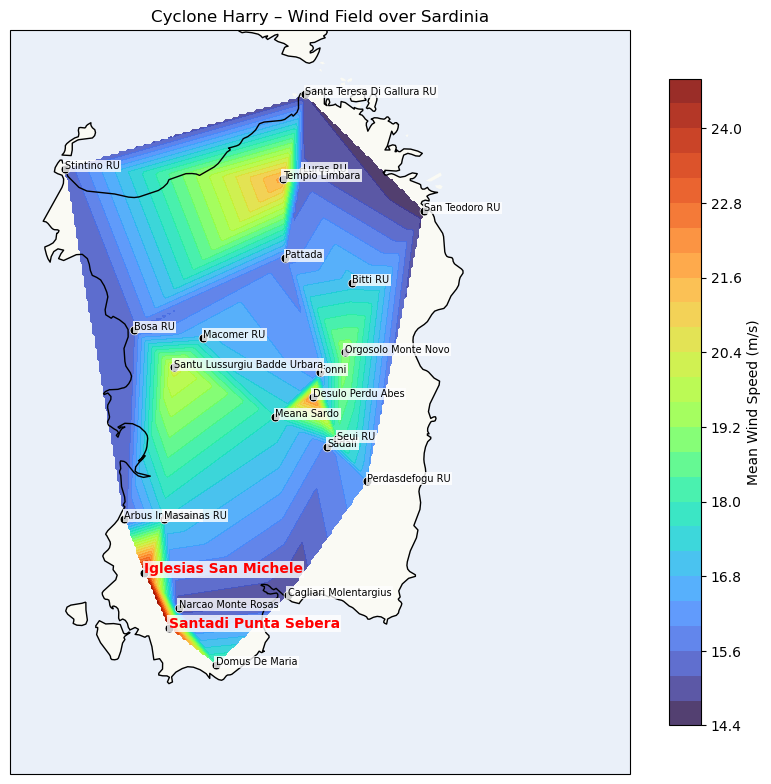

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/processed/wind.csv")
df["Stazione"] = df["Stazione"].str.strip()

coords = {
    "San Teodoro RU": (40.77, 9.67),
    "Cagliari Molentargius": (39.22, 9.12),
    "Santa Teresa Di Gallura RU": (41.24, 9.19),
    "Narcao Monte Rosas": (39.17, 8.68),
    "Arbus Ingurtosu": (39.53, 8.46),
    "Luras RU": (40.93, 9.18),
    "Stintino RU": (40.94, 8.22),
    "Bosa RU": (40.29, 8.50),
    "Pattada": (40.58, 9.11),
    "Sadali": (39.82, 9.28),
    "Fonni": (40.12, 9.25),
    "Perdasdefogu RU": (39.68, 9.44),
    "Macomer RU": (40.26, 8.78),
    "Bitti RU": (40.48, 9.38),
    "Masainas RU": (39.53, 8.62),
    "Meana Sardo": (39.94, 9.07),
    "Domus De Maria": (38.94, 8.83),
    "Seui RU": (39.85, 9.32),
    "Orgosolo Monte Novo": (40.20, 9.35),
    "Santu Lussurgiu Badde Urbara": (40.14, 8.66),
    "Tempio Limbara": (40.90, 9.10),
    "Desulo Perdu Abes": (40.02, 9.22),
    "Santadi Punta Sebera": (39.09, 8.64),
    "Iglesias San Michele": (39.31, 8.54)
}

df["lat"] = df["Stazione"].map(lambda x: coords[x][0])
df["lon"] = df["Stazione"].map(lambda x: coords[x][1])

# =========================
# DATA
# =========================
lon = df["lon"].values
lat = df["lat"].values
wind = df["Vento_medio_ms"].values

lon_grid = np.linspace(8.0, 10.5, 300)
lat_grid = np.linspace(38.5, 41.5, 300)

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

grid = griddata((lon, lat), wind, (lon_mesh, lat_mesh), method="linear")

# =========================
# MAP
# =========================
fig = plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([8.0, 10.5, 38.5, 41.5])

ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.2)

c = ax.contourf(
    lon_mesh,
    lat_mesh,
    grid,
    levels=25,
    cmap="turbo",
    alpha=0.85,
    transform=ccrs.PlateCarree()
)

plt.colorbar(c, label="Mean Wind Speed (m/s)", shrink=0.7)

# =========================
# STATIONS
# =========================
ax.scatter(
    lon,
    lat,
    color="black",
    s=40,
    edgecolors="white",
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# =========================
# LABELS (FORZATI + VISIBILI)
# =========================
highlight = {
    "Iglesias San Michele",
    "Santadi Punta Sebera"
}

for _, r in df.iterrows():

    is_highlight = r["Stazione"] in highlight

    ax.text(
        r["lon"],
        r["lat"],
        r["Stazione"],
        fontsize=10 if is_highlight else 7,
        fontweight="bold" if is_highlight else "normal",
        color="red" if is_highlight else "black",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="none",
            pad=1
        ),
        transform=ccrs.PlateCarree(),
        zorder=20
    )

# =========================
# TITLE
# =========================
plt.title("Cyclone Harry – Wind Field over Sardinia")

# =========================
# SAVE
# =========================
plt.savefig(
    "../figures/wind_field_sardinia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


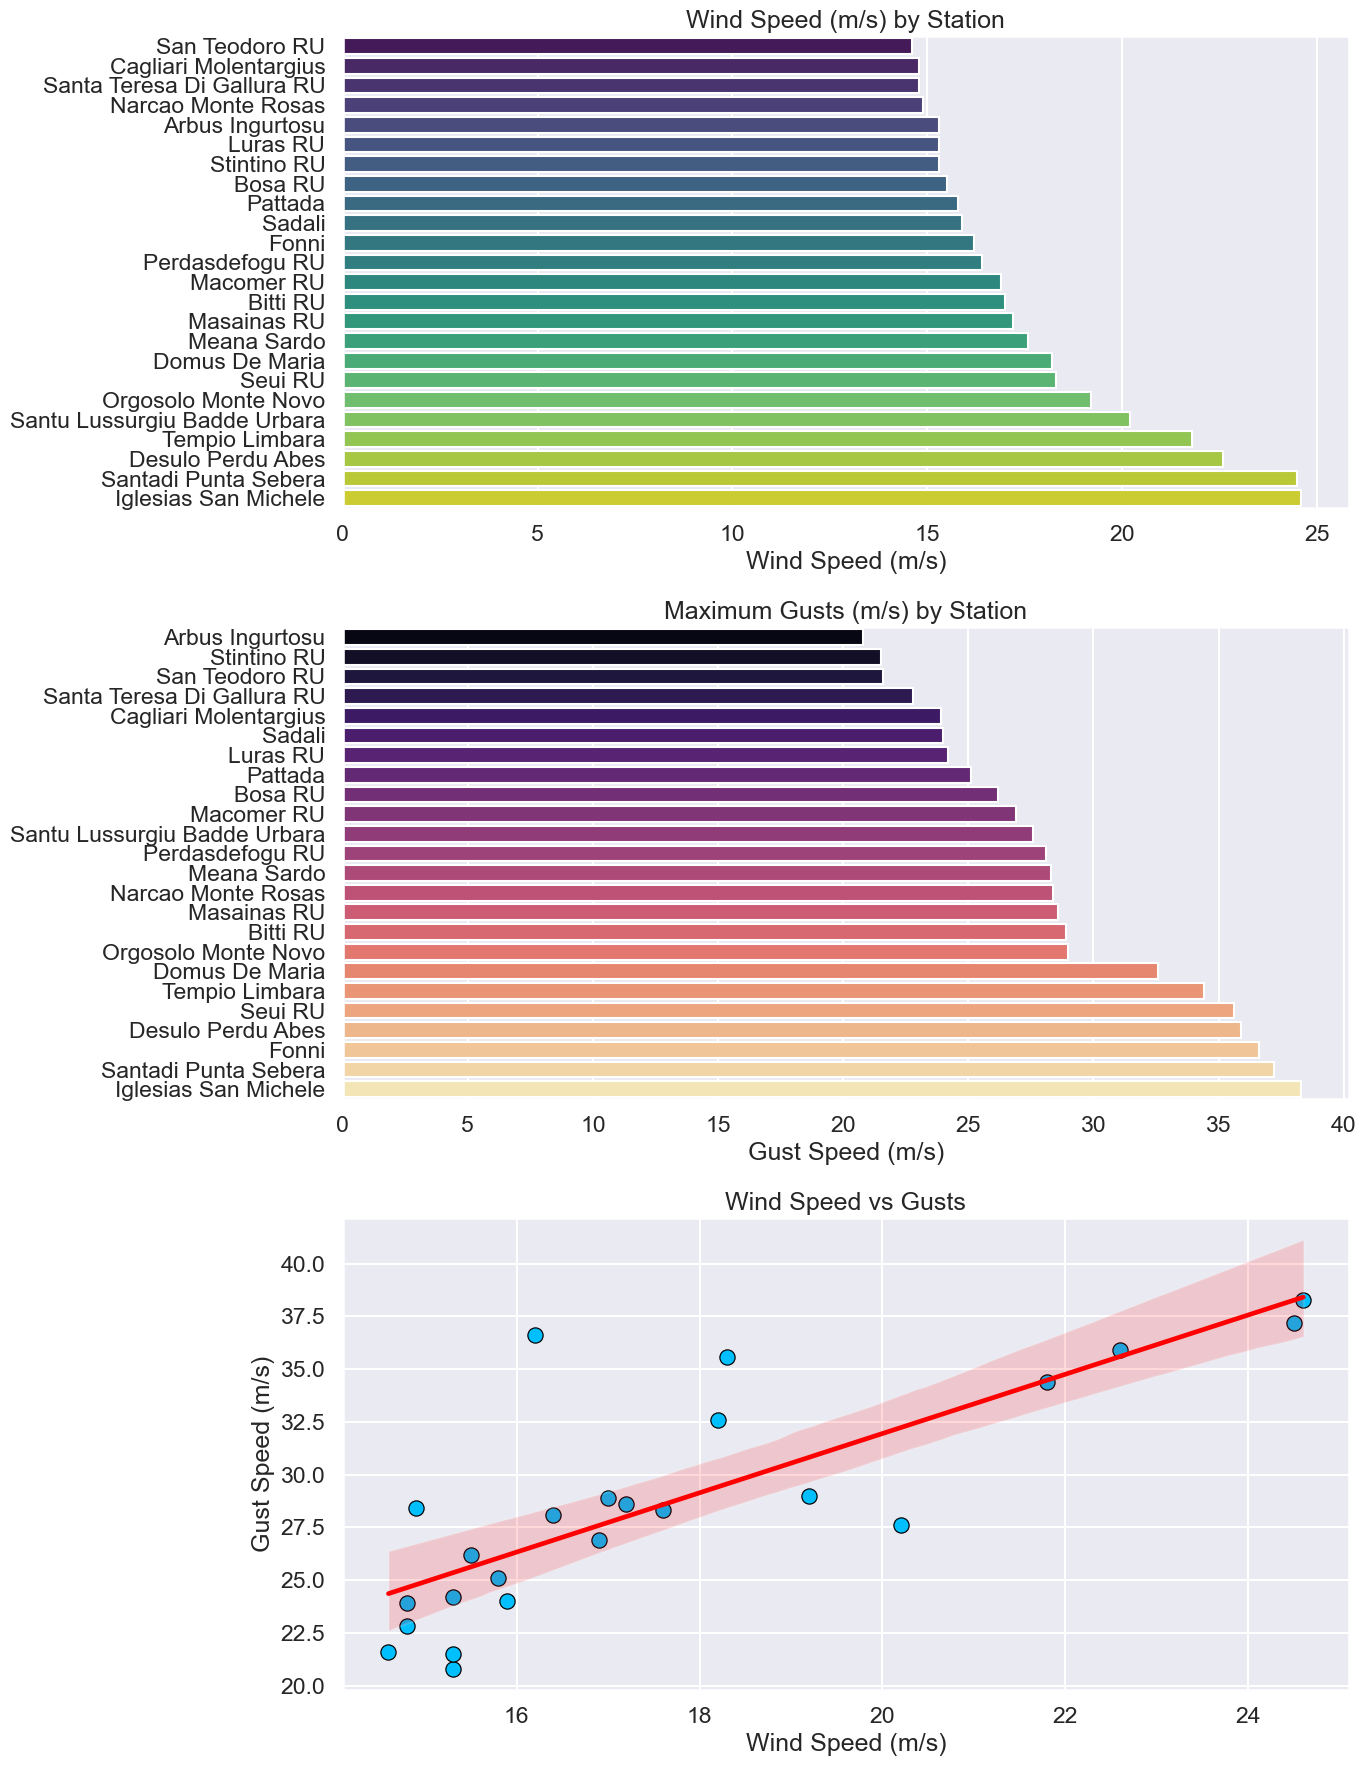

Plot salvato in: ../figures/wind_plots.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA FROM FILE
# =========================
file_path = "../data/processed/wind.csv"
df = pd.read_csv(file_path)

# clean station names
df["Stazione"] = df["Stazione"].str.strip()

# sort
df = df.sort_values("Vento_medio_ms")
df2 = df.sort_values("Raffica_ms")

# =========================
# STYLE
# =========================
sns.set_theme(style="darkgrid", context="talk")

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# =========================
# 1) WIND SPEED
# =========================
sns.barplot(
    data=df,
    y="Stazione",
    x="Vento_medio_ms",
    hue="Stazione",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Wind Speed (m/s) by Station")
axes[0].set_xlabel("Wind Speed (m/s)")
axes[0].set_ylabel("")

# =========================
# 2) GUST SPEED
# =========================
sns.barplot(
    data=df2,
    y="Stazione",
    x="Raffica_ms",
    hue="Stazione",
    dodge=False,
    palette="magma",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Maximum Gusts (m/s) by Station")
axes[1].set_xlabel("Gust Speed (m/s)")
axes[1].set_ylabel("")

# =========================
# 3) SCATTER + TREND
# =========================
sns.scatterplot(
    data=df,
    x="Vento_medio_ms",
    y="Raffica_ms",
    s=120,
    color="deepskyblue",
    edgecolor="black",
    ax=axes[2]
)

sns.regplot(
    data=df,
    x="Vento_medio_ms",
    y="Raffica_ms",
    scatter=False,
    color="red",
    ax=axes[2]
)

axes[2].set_title("Wind Speed vs Gusts")
axes[2].set_xlabel("Wind Speed (m/s)")
axes[2].set_ylabel("Gust Speed (m/s)")

# =========================
# SAVE FIGURE
# =========================
output_file = "../figures/wind_plots.png"
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot salvato in: {output_file}")


In [6]:
!pip install pdfplumber

  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached pdfminer_six-20251230-py3-none-any.whl.metadata (4.3 kB)
  Using cached cryptography-48.0.0-cp311-abi3-macosx_10_9_universal2.whl.metadata (4.3 kB)
Using cached pdfplumber-0.11.9-py3-none-any.whl (60 kB)
Using cached pdfminer_six-20251230-py3-none-any.whl (6.6 MB)
Using cached cryptography-48.0.0-cp311-abi3-macosx_10_9_universal2.whl (8.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 6.7 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1━━━━━━━━━━━━━━━━━━━━━━ 1/5 [cffi]
    Uninstalling cffi-1.17.1:0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [cffi]
      Successfully uninstalled cffi-1.17.1━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [cffi]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pdfplumber]5 [pdfplumber]x]


    rank                      station  rain_mm       basin
0      1                 Genna Tuvara    557.8  Flumendosa
1      2        Villagrande Strisaili    512.3  Flumendosa
2      3         Gairo Taquisara ARST    511.0  Flumendosa
3      4      Villagrande Bau Mandara    490.2  Flumendosa
4      5         Urzulei Genna Silana    437.0     Cedrino
5      6                        Osini    396.0  Flumendosa
6      7          Arzana Sicca d'Erba    380.7  Flumendosa
7      8                      Seui RU    368.8  Flumendosa
8      9            Seui c.ra Arqueri    341.1  Flumendosa
9     10                   Urzulei RU    328.3    Pramaera
10    11                  Ussassai RU    327.1  Flumendosa
11    12                    Seui ARST    284.1  Flumendosa
12    13              Perdasdefogu RU    273.3      Quirra
13    14            Lodè a Sas Seddas    263.0      Posada
14    15          Orgosolo Monte Novo    257.2     Cedrino
15    16                Villasalto RU    254.0  Flumendo

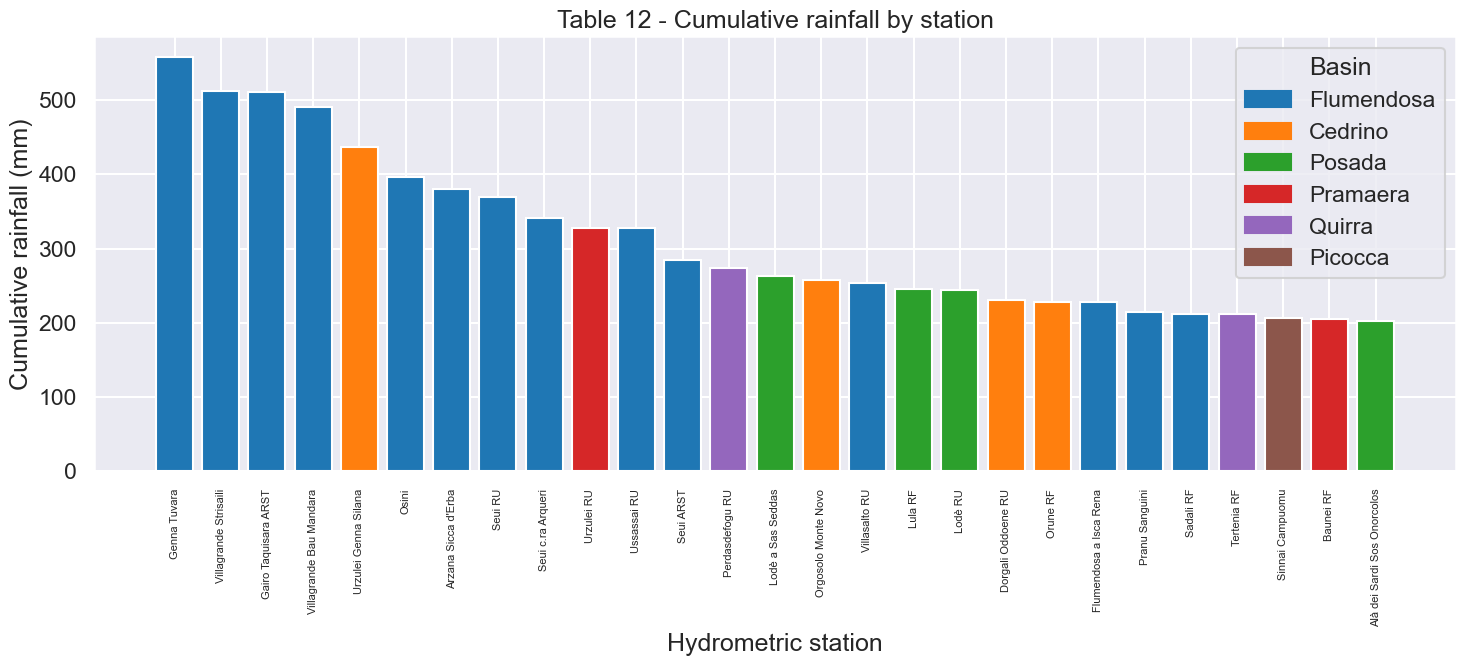

In [7]:
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

# ==========================
# INPUT FILE
# ==========================
PDF_FILE = "../data/raw/21_393_20260211152403.pdf"

records = []

# ==========================
# PARSE PDF
# ==========================
with pdfplumber.open(PDF_FILE) as pdf:

    # page 93 = index 92
    page = pdf.pages[92]

    text = page.extract_text()

    lines = text.split("\n")

    # Pattern: rank station rain basin
    pattern = re.compile(
        r"^(\d+)\s+(.+?)\s+(\d+\.\d+)\s+([A-Za-zÀ-ÿ]+)$"
    )

    for line in lines:
        line = line.strip()
        m = pattern.match(line)

        if m:
            records.append({
                "rank": int(m.group(1)),
                "station": m.group(2),
                "rain_mm": float(m.group(3)),
                "basin": m.group(4)
            })

# ==========================
# DATAFRAME
# ==========================
df = pd.DataFrame(records)

print(df)

# ==========================
# SAVE CSV
# ==========================
os.makedirs("../data/processed", exist_ok=True)

csv_path = "../data/processed/tabella12.csv"

df.to_csv(csv_path, index=False)

print(f"CSV saved: {csv_path}")

# ==========================
# SORT DATA
# ==========================
df = df.sort_values("rain_mm", ascending=False)

# ==========================
# COLOR MAP
# ==========================
colors = {
    "Flumendosa": "tab:blue",
    "Cedrino": "tab:orange",
    "Posada": "tab:green",
    "Pramaera": "tab:red",
    "Quirra": "tab:purple",
    "Picocca": "tab:brown"
}

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(15,7))

plt.bar(
    df["station"],
    df["rain_mm"],
    color=[colors.get(b, "gray") for b in df["basin"]]
)

# ==========================
# LEGEND (BASIN)
# ==========================
handles = []
labels = []

for basin, color in colors.items():
    if basin in df["basin"].values:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=color))
        labels.append(basin)

plt.legend(handles, labels, title="Basin")

# ==========================
# AXIS LABELS
# ==========================
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Cumulative rainfall (mm)")
plt.xlabel("Hydrometric station")
plt.title("Table 12 - Cumulative rainfall by station")

plt.tight_layout()

# ==========================
# SAVE FIGURE
# ==========================
os.makedirs("../figures", exist_ok=True)

figure_path = "../figures/cumulative_rainfall.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Figure saved: {figure_path}")

# ==========================
# SHOW
# ==========================
plt.show()

Salvato: ../data/processed/tabella13.csv
   id codice                       stazione        data orario  livello_m  \
0   1    F27        Riu Mannu a San Sperate  23/01/2026  07:42       1.34   
1   2    F22              Riu Cixerri a Uta  23/01/2026  10:05       1.28   
2   3    F06  Riu Murmurei a Trav. S. Lucia  23/01/2026  11:15       1.55   
3   4    F18   Riu Mannu a Villa San Pietro  23/01/2026  13:38       0.65   
4   5    F59  Riu Mannu di Ozieri a Fraigas  20/01/2026  13:11       2.28   

   portata_m3s  
0       10.727  
1       18.069  
2        4.089  
3        7.763  
4       72.470  
Grafico salvato: ../figures/MaximumDischarge.png


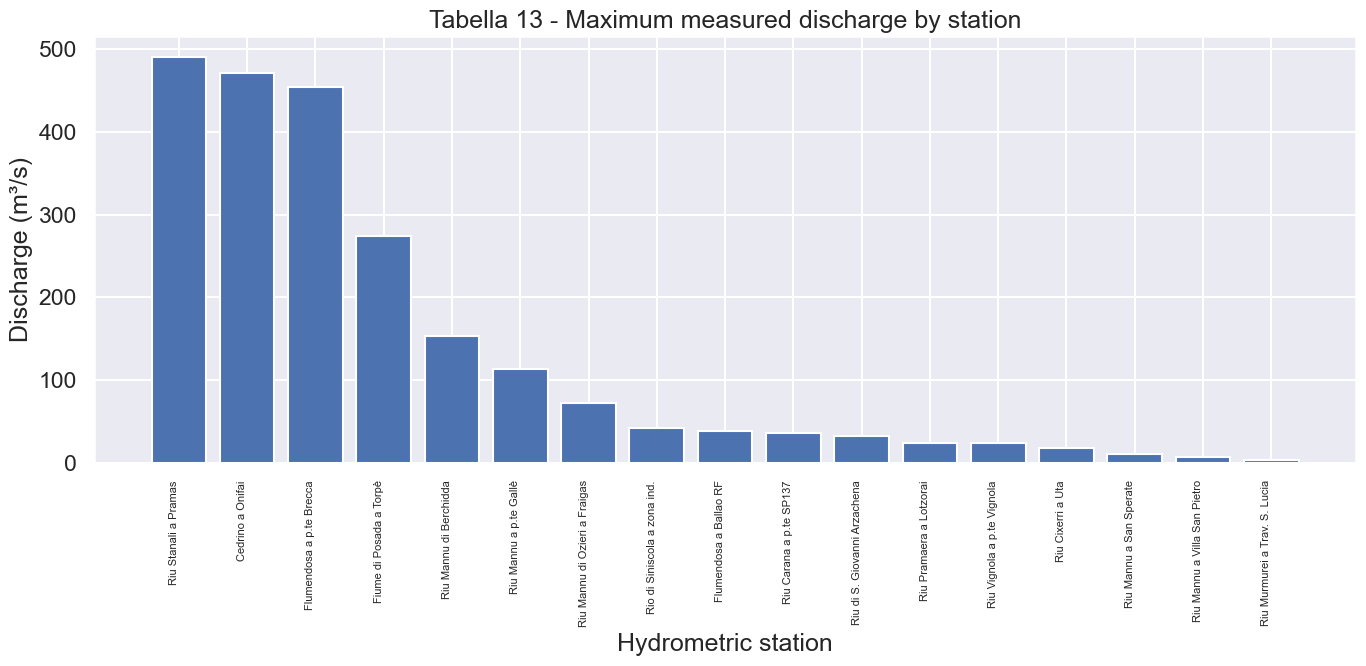

In [8]:
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

PDF_FILE = "../data/raw/21_393_20260211152403.pdf"

records = []

with pdfplumber.open(PDF_FILE) as pdf:

    # Tabella 13: pagine 94-95 => indici 93 e 94
    text = ""

    for page_idx in [93, 94]:
        text += "\n" + (pdf.pages[page_idx].extract_text() or "")

# Pattern della tabella
pattern = re.compile(
    r"(\d+)\s+"                     # numero progressivo
    r"(F\d+)\s+"                    # codice stazione
    r"(.+?)\s+"                     # nome stazione
    r"(\d{2}/\d{2}/\d{4})\s+"       # data
    r"(\d{2}:\d{2})\s+"             # orario
    r"([\d\.]+)\s+"                 # livello
    r"([\d\.]+)"                    # portata
)

for line in text.split("\n"):

    line = line.strip()

    match = pattern.match(line)

    if match:

        records.append({
            "id": int(match.group(1)),
            "codice": match.group(2),
            "stazione": match.group(3),
            "data": match.group(4),
            "orario": match.group(5),
            "livello_m": float(match.group(6)),
            "portata_m3s": float(match.group(7))
        })

df = pd.DataFrame(records)

# ==========================
# CSV
# ==========================

os.makedirs("../data/processed", exist_ok=True)

csv_file = "../data/processed/tabella13.csv"

df.to_csv(csv_file, index=False)

print(f"Salvato: {csv_file}")
print(df.head())

# ==========================
# PORTATA MASSIMA PER STAZIONE
# ==========================

df_max = (
    df.groupby("stazione", as_index=False)["portata_m3s"]
      .max()
      .sort_values("portata_m3s", ascending=False)
)

# ==========================
# GRAFICO
# ==========================

plt.figure(figsize=(14, 7))

plt.bar(
    df_max["stazione"],
    df_max["portata_m3s"]
)

plt.xticks(
    rotation=90,
    fontsize=8,
    ha="right"
)

plt.ylabel("Discharge (m³/s)")
plt.xlabel("Hydrometric station")

plt.title(
    "Tabella 13 - Maximum measured discharge by station"
)

plt.tight_layout()

os.makedirs("../figures", exist_ok=True)

figure_file = "../figures/MaximumDischarge.png"

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Grafico salvato: {figure_file}")

plt.show()


In [1]:
from IPython.display import Video
Video("Poetto.mp4")